<a href="https://colab.research.google.com/github/alaminsumon012-ux/Fake-News-Headline-Detector/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 11: Fake News Headline Detector
**Phase 1: Data Loading & Exploratory Data Analysis (EDA)**

In this first phase, we will load our dataset and explore its characteristics to understand the linguistic differences between real and fabricated news headlines.

For this project, we are using the Kaggle Fake and Real News Dataset. Since the dataset is split into two files (`True.csv` and `Fake.csv`), our first task is to load them, assign the required binary labels—**REAL (0)** and **FAKE (1)**—and merge them into a single dataframe.

After structuring the data, we will perform the following EDA tasks:
1. **Class Distribution:** Check if the dataset is balanced between real and fake headlines.
2. **Average Headline Length:** Determine if fake news tends to use longer or shorter headlines to grab attention.
3. **Word Clouds:** Visually identify the most frequent terms used in each class.
4. **Discriminative Terms:** Extract the top-20 TF-IDF terms per class to see which words mathematically define real versus fake news.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading datasets from Google Drive...
Dataset loaded successfully! Total records: 44898

--- Class Distribution ---
label
1    23481
0    21417
Name: count, dtype: int64


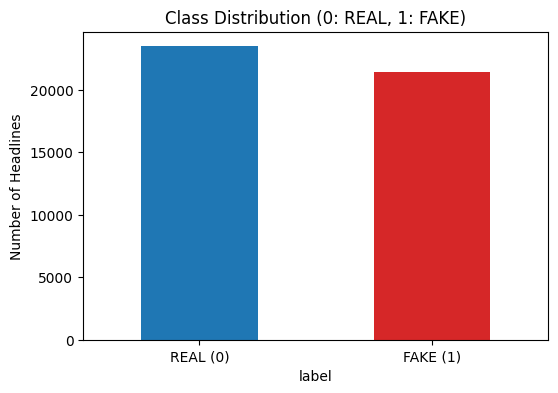


--- Average Headline Length ---
Average words in REAL headlines: 9.95
Average words in FAKE headlines: 14.73

Generating Word Clouds...


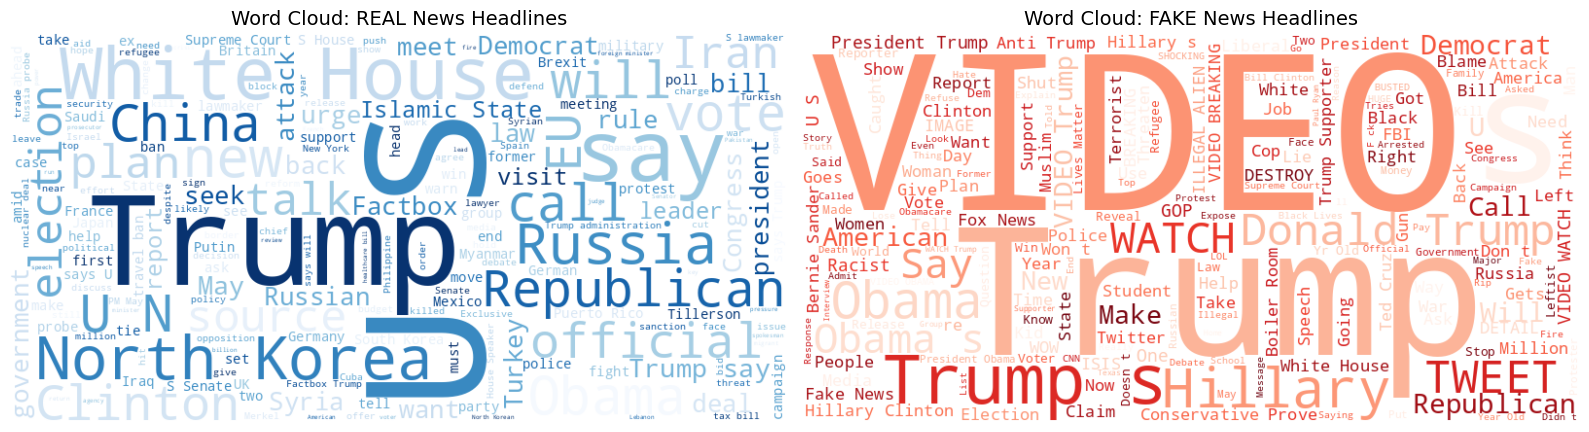


--- Top 20 Discriminative TF-IDF Terms ---

Top 20 REAL terms:
['trump', 'says', 'house', 'russia', 'north', 'korea', 'white', 'new', 'senate', 'china', 'court', 'obama', 'republican', 'clinton', 'state', 'tax', 'eu', 'election', 'deal', 'vote']

Top 20 FAKE terms:
['trump', 'video', 'obama', 'hillary', 'watch', 'just', 'clinton', 'president', 'donald', 'new', 'news', 'breaking', 'gop', 'black', 'white', 'america', 'media', 'tweets', 'muslim', 'gets']


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
print("\nLoading datasets from Google Drive...")
try:
    # Update these paths if your files are inside a specific folder on your Drive!
    true_df = pd.read_csv('/content/drive/MyDrive/True.csv')
    fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')

    # Assign labels as per project requirements: REAL (0) / FAKE (1)
    true_df['label'] = 0
    fake_df['label'] = 1

    # Combine the datasets and shuffle them
    df = pd.concat([true_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

    # We will focus exclusively on the 'title' (headline) and 'label' columns
    df = df[['title', 'label']]
    print(f"Dataset loaded successfully! Total records: {len(df)}")

except FileNotFoundError:
    print("Error: Could not find the CSV files at the specified Google Drive path.")
    print("Please check the folder path in the pd.read_csv() functions.")

# ==========================================
# 2. EDA: CLASS DISTRIBUTION
# ==========================================
print("\n--- Class Distribution ---")
class_counts = df['label'].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['#1f77b4', '#d62728'])
plt.title('Class Distribution (0: REAL, 1: FAKE)')
plt.xticks(ticks=[0, 1], labels=['REAL (0)', 'FAKE (1)'], rotation=0)
plt.ylabel('Number of Headlines')
plt.show()

# ==========================================
# 3. EDA: AVERAGE HEADLINE LENGTH
# ==========================================
print("\n--- Average Headline Length ---")
# Calculate length based on the number of words in the title
df['headline_length'] = df['title'].apply(lambda x: len(str(x).split()))

avg_length = df.groupby('label')['headline_length'].mean()
print(f"Average words in REAL headlines: {avg_length[0]:.2f}")
print(f"Average words in FAKE headlines: {avg_length[1]:.2f}")

# ==========================================
# 4. EDA: WORD CLOUDS
# ==========================================
print("\nGenerating Word Clouds...")
real_text = " ".join(df[df['label'] == 0]['title'].astype(str))
fake_text = " ".join(df[df['label'] == 1]['title'].astype(str))

wordcloud_real = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(real_text)
wordcloud_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wordcloud_real, interpolation='bilinear')
axes[0].set_title('Word Cloud: REAL News Headlines', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wordcloud_fake, interpolation='bilinear')
axes[1].set_title('Word Cloud: FAKE News Headlines', fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# 5. EDA: TOP-20 TF-IDF TERMS PER CLASS
# ==========================================
print("\n--- Top 20 Discriminative TF-IDF Terms ---")
# Initialize a basic vectorizer to find top terms
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)

def get_top_tfidf_terms(text_series, top_n=20):
    tfidf_matrix = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()

    # Sum TF-IDF scores for each word across all documents
    summed_tfidf = tfidf_matrix.sum(axis=0).A1

    # Create a DataFrame of words and their scores, then sort
    df_tfidf = pd.DataFrame({'word': feature_names, 'score': summed_tfidf})
    return df_tfidf.sort_values(by='score', ascending=False).head(top_n)

top_real_terms = get_top_tfidf_terms(df[df['label'] == 0]['title'])
top_fake_terms = get_top_tfidf_terms(df[df['label'] == 1]['title'])

print("\nTop 20 REAL terms:")
print(top_real_terms['word'].tolist())

print("\nTop 20 FAKE terms:")
print(top_fake_terms['word'].tolist())

# Phase 2: Text Preprocessing and Feature Extraction

Before we can train our machine learning models, we need to convert our raw text headlines into a format that an algorithm can understand. This involves two main steps: cleaning the text and extracting mathematical features.

**1. Text Preprocessing:**
We will clean the headlines by converting all text to lowercase and removing punctuation. Next, we will remove common English "stop-words" (like 'the', 'is', 'in') which do not carry significant predictive value. Finally, we will use the NLTK `WordNetLemmatizer` to reduce words to their base dictionary forms (e.g., converting "running" to "run").

**2. TF-IDF Feature Extraction:**
Once the text is clean, we will build a Term Frequency-Inverse Document Frequency (TF-IDF) matrix. We will extract both single words (unigrams) and two-word phrases (bigrams) to capture linguistic context. To keep our model efficient, we will cap the matrix at a maximum of 10,000 features and apply sublinear term frequency scaling (`sublinear_tf=True`) to dampen the effect of extremely frequent words.

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. DOWNLOAD NLTK RESOURCES
# ==========================================
# Colab requires us to download these specific linguistic datasets
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ==========================================
# 2. TEXT CLEANING FUNCTION
# ==========================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation using regular expressions
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize by splitting, then filter out stop-words and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing to our dataset
print("Preprocessing text... This may take a minute or two depending on dataset size.")
df['clean_title'] = df['title'].apply(preprocess_text)

print("\n--- Sample of Original vs. Cleaned Text ---")
display(df[['title', 'clean_title']].head())

# ==========================================
# 3. BUILD TF-IDF MATRIX
# ==========================================
print("\nBuilding TF-IDF feature matrix...")

# Initialize Vectorizer as per project requirements
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # Include both unigrams and bigrams
    sublinear_tf=True,     # Apply sublinear tf scaling
    max_features=10000     # Limit to top 10000 features
)

# Fit and transform the cleaned text to create our feature matrix (X)
X = tfidf_vectorizer.fit_transform(df['clean_title'])

# Define our target labels (y)
y = df['label'].values

print(f"TF-IDF Matrix Shape (X): {X.shape}")
print(f"Target Labels Shape (y): {y.shape}")
print("\nPhase 2 Complete! We are ready for model training.")

Preprocessing text... This may take a minute or two depending on dataset size.

--- Sample of Original vs. Cleaned Text ---


,title,clean_title
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley enough demand t...
1,Failed GOP Candidates Remembered In Hilarious...,failed gop candidate remembered hilarious mock...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pences new dc neighbor hilariously trolli...
3,California AG pledges to defend birth control ...,california ag pledge defend birth control insu...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,az rancher living usmexico border destroy nanc...



Building TF-IDF feature matrix...
TF-IDF Matrix Shape (X): (44898, 10000)
Target Labels Shape (y): (44898,)

Phase 2 Complete! We are ready for model training.


# Phase 3: Model Training and Comparison

In this phase, we will train three different machine learning models to classify our headlines. We will evaluate our traditional models using **5-Fold Stratified Cross-Validation** to ensure our results are robust and not dependent on a specific train/test split.

**The Models:**
1. **Logistic Regression (Baseline):** A linear model that assigns weights to our TF-IDF features. It is highly effective and interpretable for text classification.
2. **Multinomial Naive Bayes:** A probabilistic model based on Bayes' Theorem, commonly used as a benchmark in Natural Language Processing.
3. **LSTM Neural Network:** A type of Recurrent Neural Network (RNN) that processes sequences of words to capture context and word order.

*Note on Data Formats:* Our Logistic Regression and Naive Bayes models will use the `X` (TF-IDF) matrix we generated in Phase 2. However, the LSTM requires sequences of word indices. Therefore, we will create an Embedding layer and tokenize our text separately for the deep learning model.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import numpy as np

# ==========================================
# 1. TRADITIONAL ML: LOGISTIC REGRESSION & NAIVE BAYES
# ==========================================
print("--- Training Traditional Models (5-Fold CV) ---")

# Setup 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize models
log_reg = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# Evaluate Logistic Regression
print("Evaluating Logistic Regression...")
log_reg_scores = cross_val_score(log_reg, X, y, cv=skf, scoring='accuracy')
print(f"LogReg Accuracy: {log_reg_scores.mean():.4f} (+/- {log_reg_scores.std():.4f})")

# Evaluate Naive Bayes
print("Evaluating Multinomial Naive Bayes...")
nb_scores = cross_val_score(nb_model, X, y, cv=skf, scoring='accuracy')
print(f"Naive Bayes Accuracy: {nb_scores.mean():.4f} (+/- {nb_scores.std():.4f})")

# Fit the LogReg model on the full dataset so we can use it for the GUI later
log_reg.fit(X, y)

# ==========================================
# 2. DEEP LEARNING: LSTM PREPARATION
# ==========================================
print("\n--- Training Deep Learning Model (LSTM) ---")

# LSTMs need tokenized sequences, not TF-IDF
max_words = 10000  # Vocabulary size
max_len = 40       # Max words per headline (avg is much lower, so 40 is safe)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_title'])
sequences = tokenizer.texts_to_sequences(df['clean_title'])
X_seq = pad_sequences(sequences, maxlen=max_len)

# Train/Test Split specifically for the LSTM evaluation
X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, stratify=y, random_state=42
)

# ==========================================
# 3. BUILD AND TRAIN THE LSTM
# ==========================================
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binary classification
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the LSTM (Using 3 epochs to balance performance and execution time in Colab)
print("Training LSTM Model... (This will take a moment)")
history = lstm_model.fit(
    X_train_seq, y_train,
    epochs=3,
    batch_size=128,
    validation_data=(X_test_seq, y_test),
    verbose=1
)

--- Training Traditional Models (5-Fold CV) ---
Evaluating Logistic Regression...
LogReg Accuracy: 0.9439 (+/- 0.0020)
Evaluating Multinomial Naive Bayes...
Naive Bayes Accuracy: 0.9373 (+/- 0.0022)

--- Training Deep Learning Model (LSTM) ---
Training LSTM Model... (This will take a moment)
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


281/281 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.9100 - loss: 0.2243 - val_accuracy: 0.9472 - val_loss: 0.1312
Epoch 2/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.9684 - loss: 0.0887 - val_accuracy: 0.9540 - val_loss: 0.1257
Epoch 3/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.9798 - loss: 0.0584 - val_accuracy: 0.9529 - val_loss: 0.1295


# Phase 4: Model Evaluation

To thoroughly evaluate our models, we look beyond simple accuracy. In the context of fake news detection, we must balance **Precision** (avoiding false alarms where real news is flagged as fake) and **Recall** (ensuring we catch as much actual fake news as possible). The **F1-Score** provides a harmonic mean of these two metrics.

In this phase, we will generate the following evaluations:
1. **Classification Reports:** Detailed breakdown of Precision, Recall, and F1-scores.
2. **Confusion Matrices:** Visual grids showing exactly where our models are making correct predictions versus false positives/negatives.
3. **AUC-ROC Curve:** A graph showing the trade-off between the true positive rate and false positive rate. A curve closer to the top-left corner (and a higher Area Under the Curve - AUC) indicates a better model.
4. **Suspicious Word Plot:** Finally, we will extract the coefficients from our Logistic Regression model to reveal the top 20 words that are mathematically most predictive of a FAKE headline.

--- Starting Phase 4: Evaluation ---

Generating predictions for all models...
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step

--- Logistic Regression Report ---
              precision    recall  f1-score   support

    REAL (0)       0.93      0.94      0.94      4284
    FAKE (1)       0.95      0.94      0.94      4696

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


--- Naive Bayes Report ---
              precision    recall  f1-score   support

    REAL (0)       0.94      0.93      0.93      4284
    FAKE (1)       0.93      0.95      0.94      4696

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


--- LSTM Report ---
              precision    recall  f1-score   support

    REAL (0)       0.96      0.94      0.95      4284
    FAKE (1)       0.95      0.

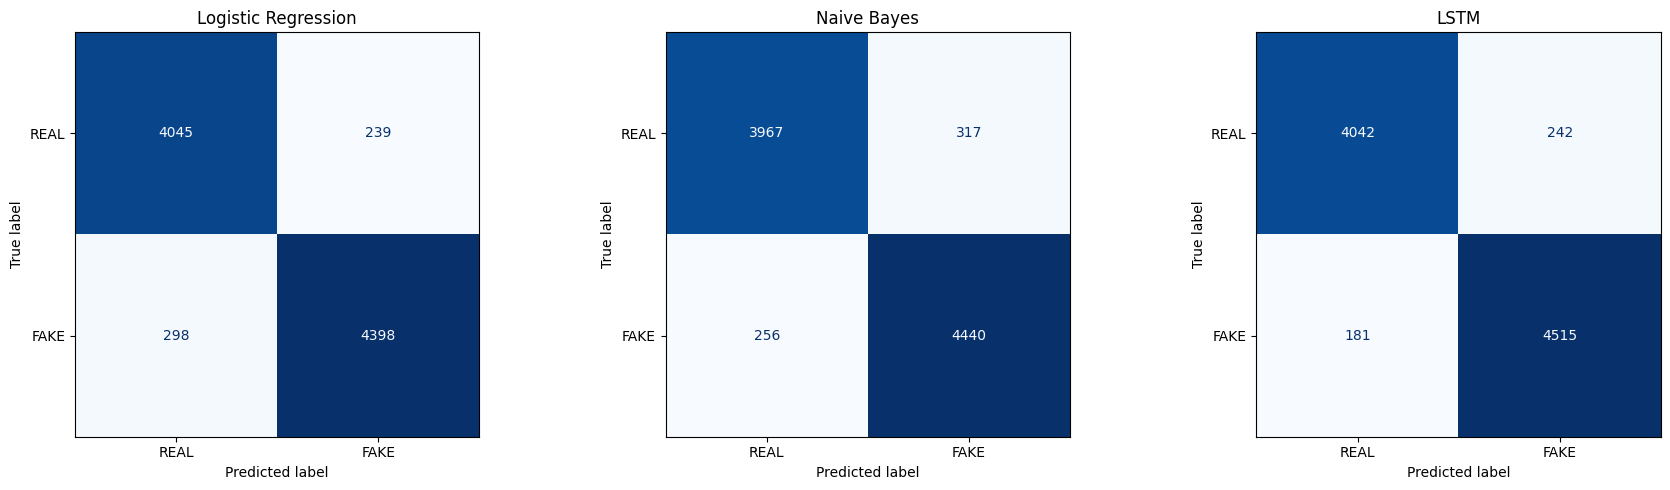

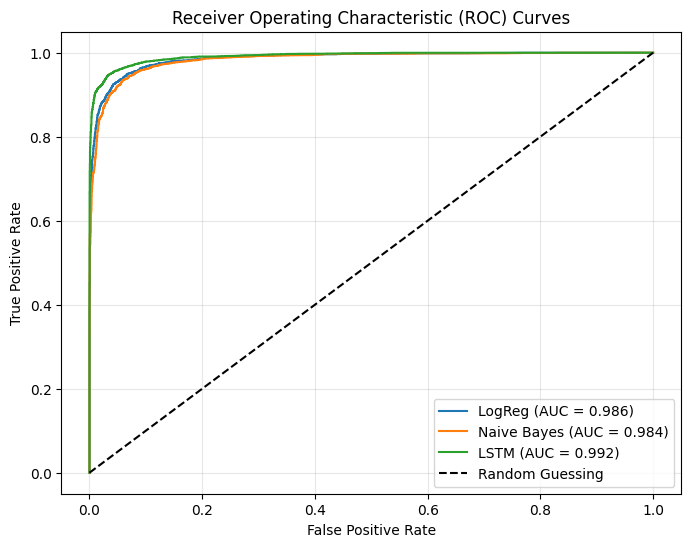


--- Top 20 Suspicious Words (Predictive of FAKE) ---


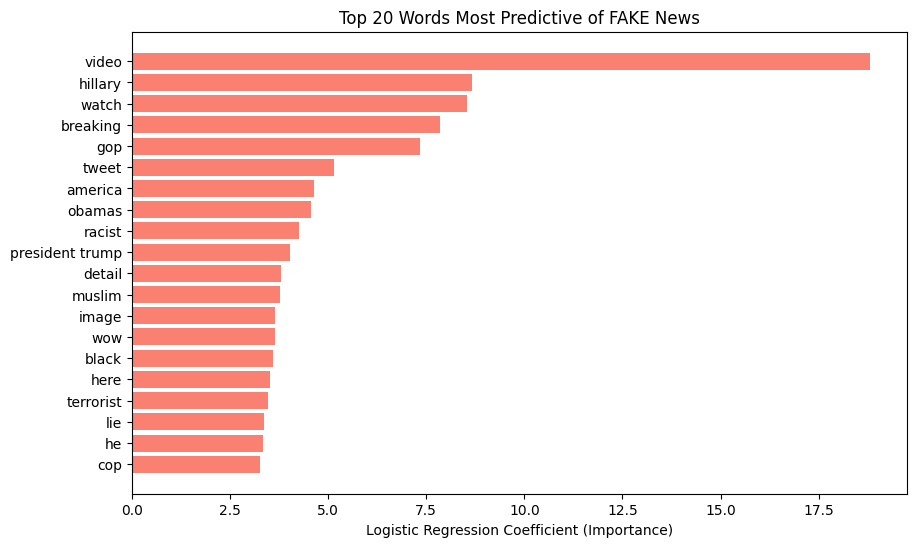

LogisticRegression(max_iter=1000)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("--- Starting Phase 4: Evaluation ---\n")

# ==========================================
# 1. PREPARE TEST DATA FOR FAIR COMPARISON
# ==========================================
# We use the same 20% test split logic used for the LSTM to evaluate our traditional models
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Fit traditional models on the training split
log_reg.fit(X_train_tf, y_train_tf)
nb_model.fit(X_train_tf, y_train_tf)

# ==========================================
# 2. GENERATE PREDICTIONS
# ==========================================
print("Generating predictions for all models...")
# Logistic Regression
y_pred_lr = log_reg.predict(X_test_tf)
y_prob_lr = log_reg.predict_proba(X_test_tf)[:, 1]

# Naive Bayes
y_pred_nb = nb_model.predict(X_test_tf)
y_prob_nb = nb_model.predict_proba(X_test_tf)[:, 1]

# LSTM
y_prob_lstm = lstm_model.predict(X_test_seq).ravel()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# ==========================================
# 3. CLASSIFICATION REPORTS
# ==========================================
print("\n--- Logistic Regression Report ---")
print(classification_report(y_test_tf, y_pred_lr, target_names=['REAL (0)', 'FAKE (1)']))

print("\n--- Naive Bayes Report ---")
print(classification_report(y_test_tf, y_pred_nb, target_names=['REAL (0)', 'FAKE (1)']))

print("\n--- LSTM Report ---")
print(classification_report(y_test, y_pred_lstm, target_names=['REAL (0)', 'FAKE (1)']))

# ==========================================
# 4. CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test_tf, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['REAL', 'FAKE']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

cm_nb = confusion_matrix(y_test_tf, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['REAL', 'FAKE']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Naive Bayes')

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm, display_labels=['REAL', 'FAKE']).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('LSTM')

plt.tight_layout()
plt.show()

# ==========================================
# 5. AUC-ROC CURVES
# ==========================================
plt.figure(figsize=(8, 6))

# Calculate ROC and AUC for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test_tf, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test_tf, y_prob_nb)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)

plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.3f})')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc(fpr_lstm, tpr_lstm):.3f})')

# Plot random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 6. TOP 20 FAKE-PREDICTIVE FEATURES
# ==========================================
print("\n--- Top 20 Suspicious Words (Predictive of FAKE) ---")
# Get feature names from the TF-IDF vectorizer
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Get the coefficients from the Logistic Regression model
coefficients = log_reg.coef_[0]

# Sort coefficients to find the most positive (predictive of FAKE = 1)
top_fake_indices = coefficients.argsort()[-20:][::-1]
top_fake_features = feature_names[top_fake_indices]
top_fake_coefs = coefficients[top_fake_indices]

# Plot the top features
plt.figure(figsize=(10, 6))
plt.barh(range(20), top_fake_coefs[::-1], color='salmon')
plt.yticks(range(20), top_fake_features[::-1])
plt.xlabel('Logistic Regression Coefficient (Importance)')
plt.title('Top 20 Words Most Predictive of FAKE News')
plt.show()

# Retrain LogReg on the full dataset for deployment in Phase 5
log_reg.fit(X, y)

# Phase 5: Graphical User Interface (GUI)

For the final deliverable, we are building an interactive interface using **Gradio**, which allows us to run the app directly within this notebook. This simulates the experience of a journalist or reader fact-checking a headline in real-time.

**GUI Features:**
1. **Input:** A text box for the user to paste any news headline.
2. **Prediction & Confidence:** The app uses our retrained Logistic Regression model to classify the text and displays a confidence percentage.
3. **Suspicious Word Highlighting (Explainability):** We extract the top mathematical features that our model associates with "FAKE" news. When the user submits a headline, the app scans it against these top terms. If it finds a match, it highlights the suspicious word in **red**, providing transparency into *why* the model made its decision.

*Note: No automated tool can replace fact-checking by a trained professional. This tool is designed to assist media literacy by flagging potentially manipulative linguistic patterns.*

In [14]:
# Install Gradio in Colab
!pip install gradio -q

import gradio as gr
import re
import numpy as np

print("--- Initializing GUI ---")

# 1. Extract the top 100 FAKE-predictive words from our Logistic Regression model
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = log_reg.coef_[0]
top_fake_indices = coefficients.argsort()[-100:][::-1] # Top 100 to cast a slightly wider net
fake_trigger_words = set(feature_names[top_fake_indices])

# 2. Define the prediction function
def predict_fake_news(headline):
    if not headline.strip():
        return "Please enter a headline.", "", ""

    # Preprocess the input
    clean_headline = preprocess_text(headline)

    # Vectorize
    vectorized_input = tfidf_vectorizer.transform([clean_headline])

    # Predict
    prediction = log_reg.predict(vectorized_input)[0]
    probabilities = log_reg.predict_proba(vectorized_input)[0]

    # Determine verdict and confidence
    if prediction == 1:
        verdict = "🚨 FAKE NEWS DETECTED"
        confidence = f"{probabilities[1] * 100:.2f}%"
    else:
        verdict = "✅ LIKELY REAL NEWS"
        confidence = f"{probabilities[0] * 100:.2f}%"

    # 3. Highlighting Logic
    # Split original headline to preserve capitalization, but check against lemmatized trigger words
    original_words = headline.split()
    highlighted_html = "<div style='font-size: 18px; padding: 10px; background-color: #f9f9f9; border-radius: 5px;'>"

    for word in original_words:
        # Clean the word just like we did in preprocessing to check against our trigger list
        clean_w = re.sub(r'[^\w\s]', '', word).lower()
        clean_w = lemmatizer.lemmatize(clean_w)

        if clean_w in fake_trigger_words:
            # Highlight in red and bold
            highlighted_html += f"<span style='color: #d62728; font-weight: bold;'>{word}</span> "
        else:
            highlighted_html += f"{word} "

    highlighted_html += "</div>"

    return verdict, confidence, highlighted_html

# 3. Build the Gradio Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 📰 Fake News Headline Detector")
    gr.Markdown("Enter a news headline below to fact-check it. Suspicious words that influenced the model will be highlighted.")

    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(lines=3, placeholder="Paste a news headline here...", label="Headline Input")
            submit_btn = gr.Button("Analyze Headline", variant="primary")

            gr.Markdown("**Disclaimer:** No automated tool can replace fact-checking by a trained journalist. This system detects linguistic patterns, not factual accuracy.")

        with gr.Column(scale=1):
            out_verdict = gr.Textbox(label="Verdict")
            out_confidence = gr.Textbox(label="Confidence Score")

    with gr.Row():
        out_highlight = gr.HTML(label="Suspicious Word Analysis")

    # Link the button to the function
    submit_btn.click(
        fn=predict_fake_news,
        inputs=input_text,
        outputs=[out_verdict, out_confidence, out_highlight]
    )

# 4. Launch the app inline in Colab
demo.launch(share=True, debug=False)

--- Initializing GUI ---


/tmp/ipykernel_8063/1652717840.py:60: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6f0aba846a84464a4c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
